# Q0. What does ClinVar contain about missense variants, and which are suitable for reliable evaluation?

Full-file audit and proposed broad SNV cohort. **Development data; no untouched holdout.** Missense selection for the frozen pilot is documented in [Q1](Q1-clinvar-split.ipynb).

[Dependencies](../requirements.txt) · [Code](src/q0.py) · CPU only · No random sampling

## 1. Input

GRCh38 · **6 July 2026 (`2026-07-06`)** · [Pinned NCBI archive](https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/archive_2.0/2026/clinvar_20260706.vcf.gz).

The first code cell downloads `data/clinvar_20260706.vcf.gz` when needed, checks NCBI’s published MD5, and decompresses it to **`data/clinvar_20260706.vcf`**. If the VCF already exists, it is reused after SHA-256 verification; an existing verified archive is decompressed without downloading again. Files are published only after checksum validation. The VCF header must identify the requested date and assembly.

The existing Q1/Q2 missense pilot remains pinned to the **5 September 2026** snapshot in `data/clinvar.vcf`. Its variants and split assignments are independent of this Q0 download.

In [1]:
from src import q0

variants, provenance, started = q0.load_data()

Read 500,000 records


Read 1,000,000 records


Read 1,500,000 records


Read 2,000,000 records


Read 2,500,000 records


Read 3,000,000 records


Read 3,500,000 records


Read 4,000,000 records


4,439,617 records · GRCh38 · 2026-07-06


## 2. Composition

Genes and consequences can have multiple annotations per record. [VCF coverage](https://www.ncbi.nlm.nih.gov/clinvar/docs/ftp_primer/).

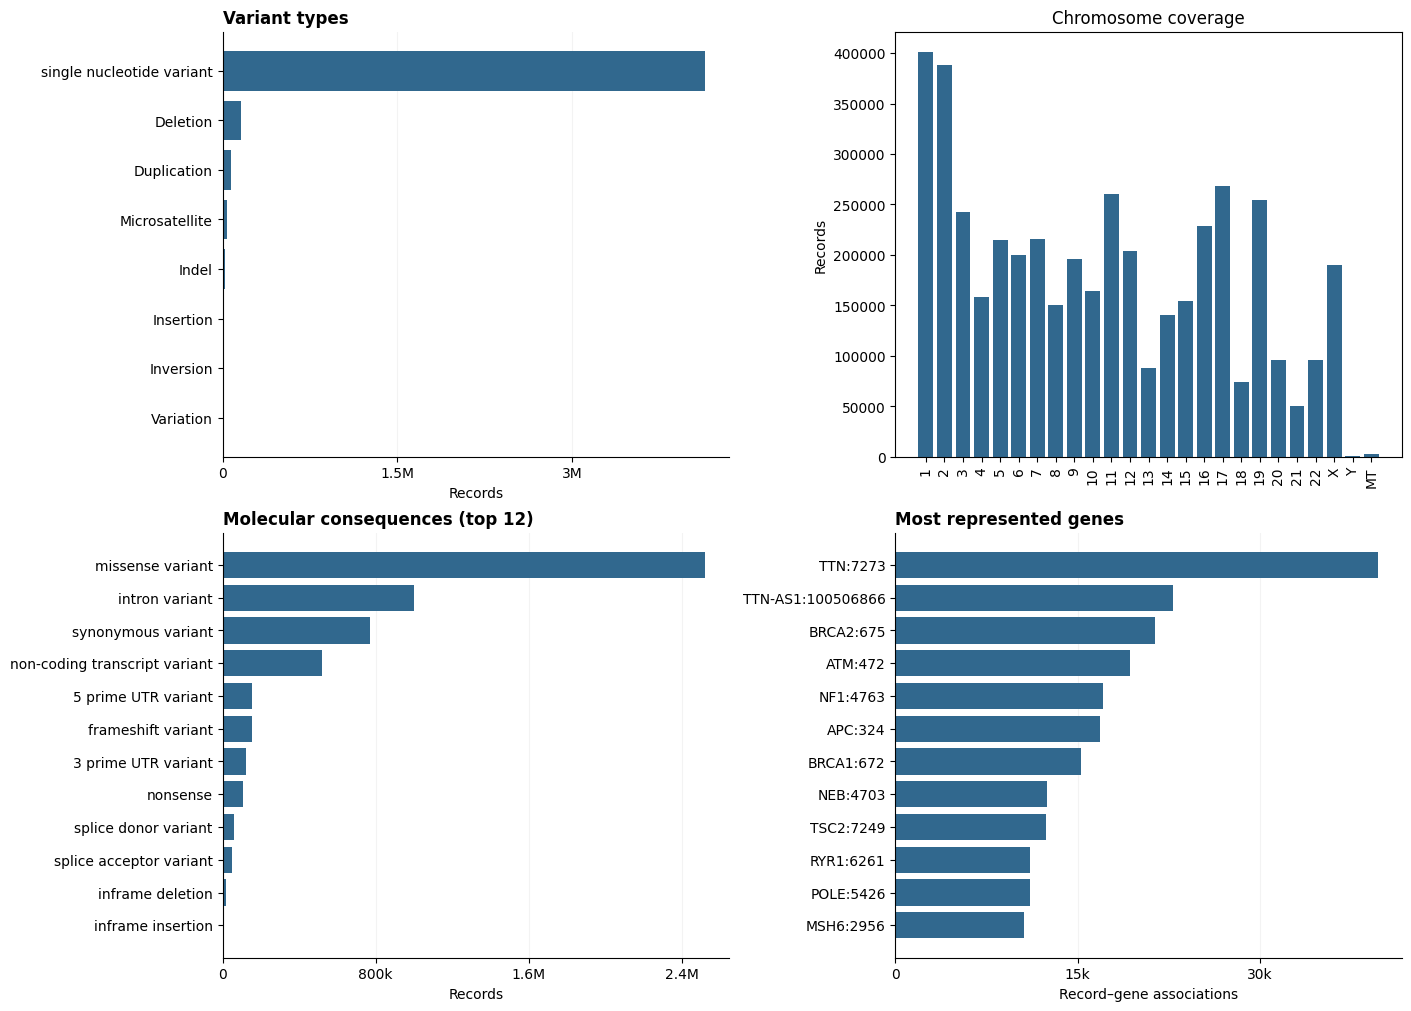

In [2]:
q0.plot_composition(variants)

## 3. Labels and review

Germline labels only. [Review stars](https://www.ncbi.nlm.nih.gov/clinvar/docs/review_status/) describe supporting review, not guaranteed correctness. Exact mappings are below.

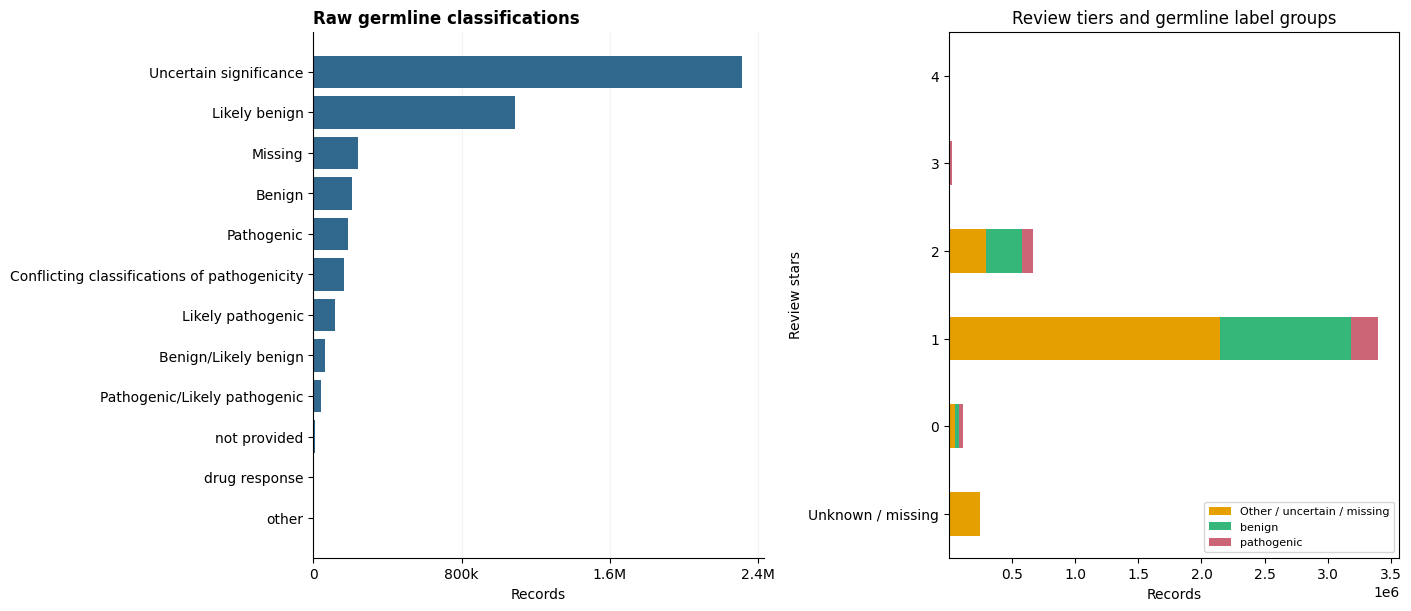

In [3]:
q0.show_classifications(variants)

## 4. Data quality

Count missing annotations, conflicts, duplicates, and shared loci. Invalid input or violated cohort rules stop execution.

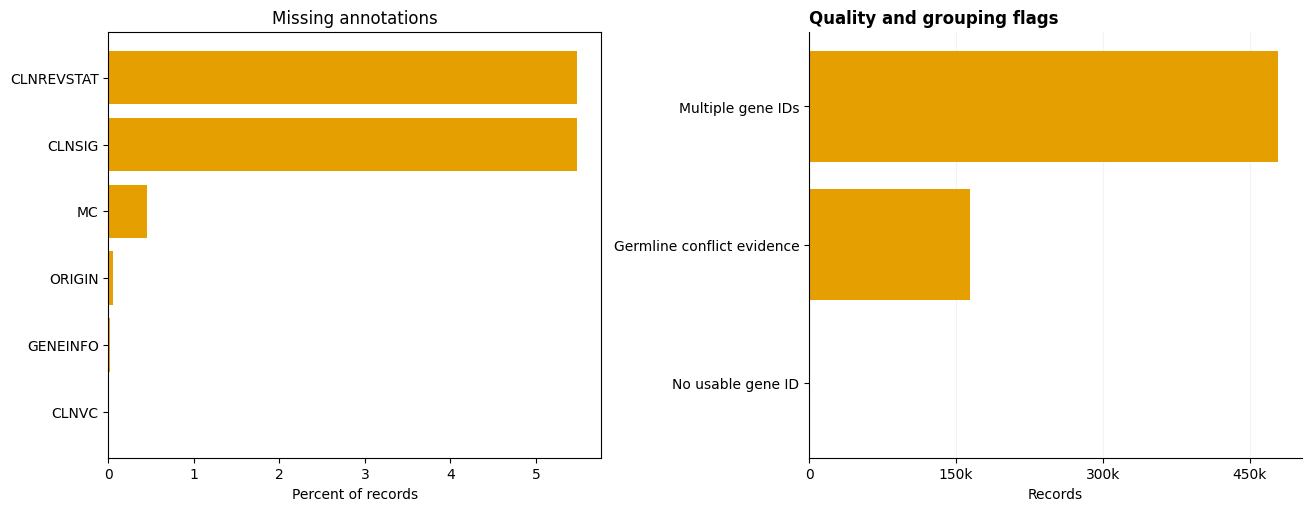

,count
CLNREVSTAT,
,243569
no_classification_for_the_single_variant,668
no_classifications_from_unflagged_records,146


In [4]:
audit = q0.show_quality(variants)

## 5. Potential leakage

Group overlapping **8,192-base coordinate windows** transitively. These proxies do not verify sequence identity or contamination; full limitations are below. Freeze related groups before modeling.

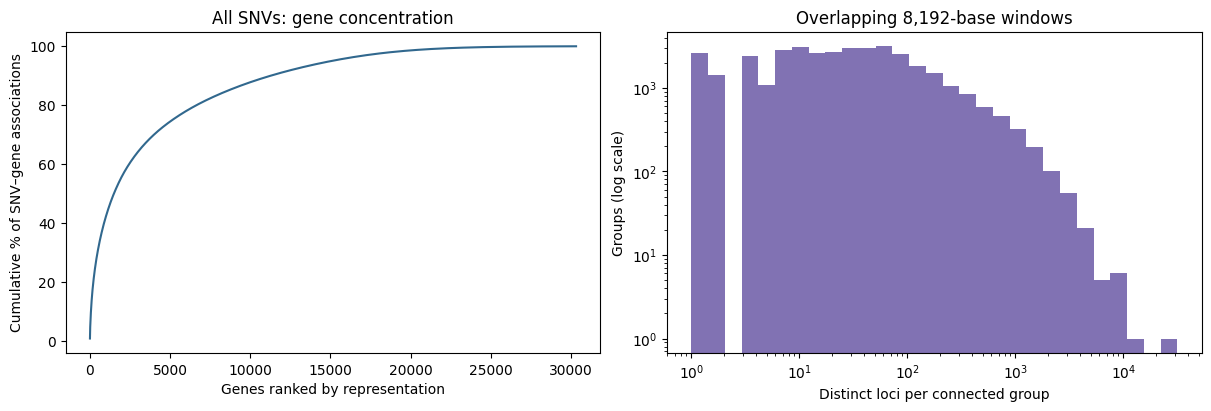

In [5]:
q0.show_grouping(variants)

## 6. Proposed cohort

Single-base A/C/G/T substitutions on chromosomes 1–22/X/Y; clear benign/pathogenic labels; **≥2 review stars**; usable gene IDs.

Exclude conflicts and inconsistent duplicates. Collapse consistent duplicates, preserving source IDs and gene associations.

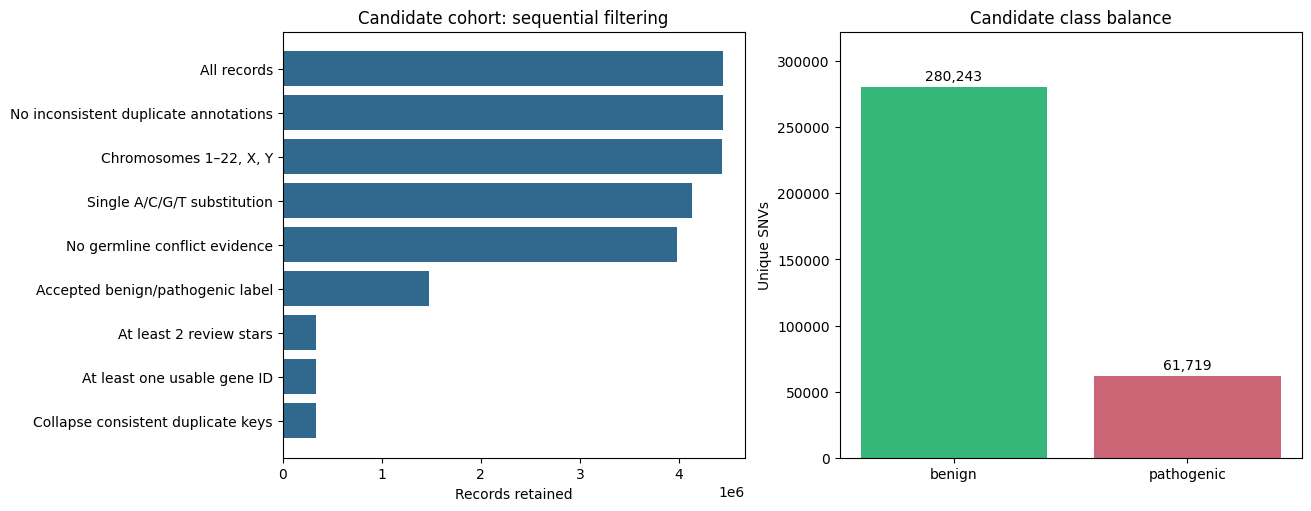

,stage,retained,removed
0,All records,4439617,0
1,No inconsistent duplicate annotations,4439617,0
2,"Chromosomes 1–22, X, Y",4436444,3173
3,Single A/C/G/T substitution,4131652,304792
4,No germline conflict evidence,3974046,157606
5,Accepted benign/pathogenic label,1476932,2497114
6,At least 2 review stars,341963,1134969
7,At least one usable gene ID,341962,1
8,Collapse consistent duplicate keys,341962,0


,chrom,pos,ref,alt,CLNSIG,CLNREVSTAT,gene_ids
67,1,930204,G,A,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
83,1,930248,G,A,Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
98,1,930282,G,A,Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
106,1,930314,C,T,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
137,1,931042,C,T,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
168,1,935779,G,A,Benign/Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
189,1,935835,C,G,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
200,1,935849,G,C,Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
206,1,935859,C,T,Benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398
224,1,935907,C,T,Likely_benign,"criteria_provided,_multiple_submitters,_no_conflicts",148398


In [6]:
cohort, funnel = q0.show_cohort(variants, audit)

In [7]:
summary = q0.save_results(variants, cohort, funnel, audit, provenance, started)

Exported 341,962 proposed variants across 13,489 gene IDs to /root/gamow/notebooks/results/q0
Completed in 2.1 minutes (CPU).


[Summary](results/q0/summary.json) · [Filter counts](results/q0/filter_counts.csv) · [Cohort](results/q0/cohort.csv.gz) · [Environment](results/q0/environment.json)

## Conclusion

The summaries above describe the **6 July 2026** ClinVar snapshot and its broad SNV eligibility cohort. Missense annotation is an additional requirement for modeling; the existing Q1/Q2 pilot continues to use its separately pinned September snapshot.